In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from pipelines.ml_benchmark import run_benchmark_pipeline

/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_btc_price = pd.read_csv("../data/gold/market/btc_usdt_1d_features.csv")
df_eth_price = pd.read_csv("../data/gold/market/eth_usdt_1d_features.csv")
df_btc_media = pd.read_csv("../data/gold/bitcoin_tone_gold.csv")

In [3]:
df_btc_media = df_btc_media[df_btc_media["date"] >= df_btc_price["open_time"].min()]
print(f"After filtering, {df_btc_media.shape[0]} rows remain in the media dataset.")
df_btc_media = df_btc_media[df_btc_media["date"] <= df_btc_price["open_time"].max()]
print(f"After filtering, {df_btc_media.shape[0]} rows remain in the media dataset.")

After filtering, 3096 rows remain in the media dataset.
After filtering, 3096 rows remain in the media dataset.


In [4]:
df_btc_media["date"] = pd.to_datetime(df_btc_media["date"])
df_btc_price["open_time"] = pd.to_datetime(df_btc_price["open_time"])

original_dates = set(df_btc_media["date"])

df_btc_media = (
    df_btc_media
    .set_index("date")
    .reindex(df_btc_price["open_time"])
    .rename_axis("date")
    .reset_index()
)

cols_to_fill = [
    "avg_tone",
    "article_count",
    "tone_ma_7",
    "tone_ma_30",
    "tone_lag_1",
    "tone_lag_7",
    "article_count_ma_3",
    "article_count_lag_1"
]

df_btc_media["was_added"] = ~df_btc_media["date"].isin(original_dates)

df_btc_media[cols_to_fill] = df_btc_media[cols_to_fill].ffill()

print(f"After reindexing, {df_btc_media.shape[0]} rows remain in the media dataset.")

df_added = df_btc_media[df_btc_media["was_added"]]

print(f"{df_added.shape[0]} rows were added by reindexing.")

df_added.head()

After reindexing, 3115 rows remain in the media dataset.
19 rows were added by reindexing.


,date,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1,was_added
2829,2025-06-15,-0.520104,115.0,-0.147458,-0.088632,-0.861521,-0.246405,211.333333,263.0,True
2830,2025-06-16,-0.520104,115.0,-0.147458,-0.088632,-0.861521,-0.246405,211.333333,263.0,True
2831,2025-06-17,-0.520104,115.0,-0.147458,-0.088632,-0.861521,-0.246405,211.333333,263.0,True
2832,2025-06-18,-0.520104,115.0,-0.147458,-0.088632,-0.861521,-0.246405,211.333333,263.0,True
2833,2025-06-19,-0.520104,115.0,-0.147458,-0.088632,-0.861521,-0.246405,211.333333,263.0,True


In [5]:
df_btc_media_and_price = pd.merge(df_btc_price, df_btc_media, left_on="open_time", right_on="date", how="inner")
df_btc_media_and_price.head()
df_btc_media_and_price.columns
df_btc_media_and_price.drop(columns=["open_time", "date", "was_added"], inplace=True)

In [6]:
df_btc_media_and_price = pd.merge(df_btc_price, df_btc_media, left_on="open_time", right_on="date", how="inner")
df_btc_media_and_price.head()
df_btc_media_and_price.columns
df_btc_media_and_price.drop(columns=["date"], inplace=True)

In [7]:
SELECTED_FEATURES = [
    "open_time",
    # Momentum
    "return_1d", "return_7d",


    # Volatility
    "volatility_7d", "volatility_30d",

    # Market behavior
    "buy_pressure",
    "close",

    # Risk
    "drawdown",

    # Trend
    "ma_ratio",

    # Lags
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",

    # Additional
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "taker_buy_base_volume",
    "number_of_trades",
    "quote_asset_volume",

    # Media features
    "avg_tone",
    "article_count",
    "tone_ma_7",
    "tone_lag_1",
    "article_count_ma_3",
    "article_count_lag_1",
]

TARGET = "target"

df_btc_media_and_price = df_btc_media_and_price[SELECTED_FEATURES + [TARGET]]
df_btc_media_and_price.head()

,open_time,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,close,drawdown,ma_ratio,lag_return_1d,...,taker_buy_base_volume,number_of_trades,quote_asset_volume,avg_tone,article_count,tone_ma_7,tone_lag_1,article_count_ma_3,article_count_lag_1,target
0,2017-09-16,0.004041,-0.127702,0.104128,0.060268,0.481585,3714.95,-0.231640,0.911502,0.160231,...,624.887842,8809,4.804878e+06,-1.715865,372.0,-1.895764,-2.099644,776.666667,1020.0,1
1,2017-09-17,-0.004027,-0.104199,0.103943,0.059834,0.401559,3699.99,-0.234734,0.899889,0.004041,...,273.931976,6355,2.466490e+06,-1.658053,287.0,-1.998736,-1.715865,559.666667,372.0,1
2,2017-09-18,0.090546,-0.041217,0.110665,0.062149,0.405472,4035.01,-0.165443,0.894766,-0.004027,...,417.638722,8220,4.069033e+06,-1.314142,634.0,-1.939380,-1.658053,431.000000,287.0,1
3,2017-09-19,-0.030971,-0.060926,0.111239,0.062376,0.285173,3910.04,-0.191290,0.887418,0.090546,...,257.320352,7342,3.558315e+06,-1.070752,586.0,-1.777034,-1.314142,502.333333,634.0,1
4,2017-09-20,-0.002568,-0.011329,0.109144,0.062290,0.548281,3900.00,-0.193367,0.886718,-0.030971,...,395.275138,7231,2.839584e+06,-0.978995,400.0,-1.599995,-1.070752,540.000000,586.0,0


In [8]:
# =========================
# 1. COPY DATA
# =========================

df_eth = df_eth_price.copy()

df_eth["open_time"] = pd.to_datetime(df_eth["open_time"])
df_btc_media_and_price["open_time"] = pd.to_datetime(df_btc_media_and_price["open_time"])


# =========================
# PRIORITY 1 — ETH FEATURES
# =========================

# ETH short-term return (1 day momentum)
df_eth["eth_return_1d"] = df_eth["close"].pct_change()

# ETH medium-term return (7 days trend)
df_eth["eth_return_7d"] = df_eth["close"].pct_change(7)

# ETH short-term volatility (market stress)
df_eth["eth_volatility_7d"] = df_eth["eth_return_1d"].rolling(7).std()

# ETH drawdown (distance from recent peak)
df_eth["eth_cummax"] = df_eth["close"].cummax()
df_eth["eth_drawdown"] = (df_eth["close"] - df_eth["eth_cummax"]) / df_eth["eth_cummax"]


# =========================
# MERGE BTC + ETH
# =========================

df_merged = pd.merge(
    df_btc_media_and_price,
    df_eth,
    on="open_time",
    how="inner",
    suffixes=("_btc", "_eth"),
)


# =========================
# PRIORITY 1 — CROSS FEATURES
# =========================

# BTC / ETH price ratio (market dominance)
df_merged["btc_eth_ratio"] = df_merged["close_btc"] / df_merged["close_eth"]

# Change in BTC/ETH ratio (capital rotation)
df_merged["btc_eth_ratio_return_7d"] = df_merged["btc_eth_ratio"].pct_change(7)


# =========================
# PRIORITY 2 — USEFUL FEATURES
# =========================

# ETH medium-short return (3 days acceleration)
df_merged["eth_return_3d"] = df_merged["close_eth"].pct_change(3)

# ETH long-term volatility (market regime)
df_merged["eth_volatility_30d"] = df_merged["eth_return_1d"].rolling(30).std()

# ETH normalized volume (detect abnormal activity)
df_merged["eth_volume_norm"] = (
    df_merged["volume_eth"] / df_merged["volume_eth"].rolling(30).mean()
)

# Relative performance BTC vs ETH
df_merged["btc_minus_eth_return_7d"] = (
    df_merged["return_7d_btc"] - df_merged["eth_return_7d"]
)


# =========================
# PRIORITY 3 — ADVANCED FEATURES
# =========================

# ETH buy pressure (aggressive buying intensity)
df_merged["eth_buy_pressure"] = (
    df_merged["taker_buy_base_volume_eth"] / df_merged["volume_eth"]
)

# Relative volatility BTC vs ETH
df_merged["btc_eth_vol_ratio"] = (
    df_merged["volatility_7d_btc"] / df_merged["eth_volatility_7d"]
)

# Global market proxy (combined momentum)
df_merged["market_return_proxy_7d"] = (
    0.5 * df_merged["return_7d_btc"] + 0.5 * df_merged["eth_return_7d"]
)


# =========================
# FINAL FEATURE SELECTION
# =========================

eth_feature_cols = [
    "open_time",

    # PRIORITY 1
    "eth_return_1d",
    "eth_return_7d",
    "eth_volatility_7d",
    "eth_drawdown",
    "btc_eth_ratio",
    "btc_eth_ratio_return_7d",

    # PRIORITY 2
    "eth_return_3d",
    "eth_volatility_30d",
    "eth_volume_norm",
    "btc_minus_eth_return_7d",

    # PRIORITY 3
    "eth_buy_pressure",
    "btc_eth_vol_ratio",
    "market_return_proxy_7d",
]

df_eth_features = df_merged[eth_feature_cols].copy()


# =========================
# CLEAN NA
# =========================

df_eth_features = df_eth_features.dropna().reset_index(drop=True)

In [9]:
# =========================
# FEATURE SELECTION MODE
# =========================

PRIORITY_LEVEL = 2  # change to 2 or 3 easily


priority_1 = [
    "eth_return_1d",
    "eth_return_7d",
    "eth_volatility_7d",
    "eth_drawdown",
    "btc_eth_ratio",
    "btc_eth_ratio_return_7d",
]

priority_2 = [
    "eth_return_3d",
    "eth_volatility_30d",
    "eth_volume_norm",
    "btc_minus_eth_return_7d",
]

priority_3 = [
    "eth_buy_pressure",
    "btc_eth_vol_ratio",
    "market_return_proxy_7d",
]


# Build feature list dynamically
selected_features = ["open_time"]

if PRIORITY_LEVEL >= 1:
    selected_features += priority_1

if PRIORITY_LEVEL >= 2:
    selected_features += priority_2

if PRIORITY_LEVEL >= 3:
    selected_features += priority_3


# Final dataframe
df_eth_features = df_merged[selected_features].copy()

# Clean
df_eth_features = df_eth_features.dropna().reset_index(drop=True)

In [10]:
# =========================
# MERGE FEATURES INTO BTC
# =========================

df_features = df_merged[selected_features].copy()

# Merge back into BTC dataframe
df_btc_media_and_price = pd.merge(
    df_btc_media_and_price,
    df_features,
    on="open_time",
    how="left"
)

# Clean
df_btc_media_and_price = df_btc_media_and_price.dropna().reset_index(drop=True)

In [ ]:
SELECTED_FEATURES = [
    # Momentum
    "return_1d", "return_7d",

    # Volatility
    "volatility_7d", "volatility_30d",

    # Market behavior
    "buy_pressure",

    # Risk
    "drawdown",

    # Trend
    "ma_ratio",

    # Lags
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",

    # Additional
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "number_of_trades",
    "quote_asset_volume",

    # ETH features
    "eth_return_1d",
    "eth_return_7d",
    "eth_volatility_7d",
    "eth_drawdown",
    "btc_eth_ratio",
    "btc_eth_ratio_return_7d",

    # Additional ETH features
    "eth_return_3d",
    "eth_volatility_30d",
    "eth_volume_norm",
    "btc_minus_eth_return_7d",

    # Media features
    "avg_tone",

]

TARGET = "target"

df_btc_media_and_price = df_btc_media_and_price[SELECTED_FEATURES + [TARGET]]
df_btc_media_and_price.head()

,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,drawdown,ma_ratio,lag_return_1d,lag_return_7d,lag_volatility_7d,...,eth_return_7d,eth_volatility_7d,eth_drawdown,btc_eth_ratio,btc_eth_ratio_return_7d,eth_return_3d,eth_volatility_30d,eth_volume_norm,btc_minus_eth_return_7d,target
0,0.008762,0.203276,0.049289,0.041585,0.470386,-0.018734,1.227793,-0.027257,0.230601,0.048571,...,0.127864,0.042620,-0.019912,17.184343,0.066862,-0.008196,0.047625,1.634143,0.075411,1
1,-0.028649,0.169753,0.052965,0.042222,0.481699,-0.046847,1.236358,0.008762,0.203276,0.049289,...,0.055418,0.051917,-0.078392,17.751198,0.108332,-0.078392,0.049127,1.503289,0.114335,0
2,-0.014824,0.143242,0.054772,0.040022,0.448538,-0.060976,1.244688,-0.028649,0.169753,0.052965,...,0.018716,0.052599,-0.094444,17.798063,0.122237,-0.083619,0.042063,2.259806,0.124525,0
3,0.031175,0.046759,0.030691,0.039367,0.460308,-0.031702,1.236566,-0.014824,0.143242,0.054772,...,0.015362,0.052654,-0.097485,18.414761,0.030921,-0.079149,0.041454,1.461320,0.031396,0
4,0.057374,0.063722,0.034222,0.040050,0.422224,0.000000,1.228949,0.031175,0.046759,0.030691,...,-0.098976,0.022063,-0.109620,19.736659,0.180571,-0.033884,0.041527,1.410720,0.162699,0


[I 2026-04-01 17:44:26,141] A new study created in memory with name: no-name-2b71bd14-a5eb-4b1f-93c2-8e2cf2d4445e
[I 2026-04-01 17:44:26,159] Trial 0 finished with value: 0.12262773722627737 and parameters: {}. Best is trial 0 with value: 0.12262773722627737.



MODEL: dummy


[I 2026-04-01 17:44:26,175] Trial 1 finished with value: 0.12262773722627737 and parameters: {}. Best is trial 0 with value: 0.12262773722627737.
[I 2026-04-01 17:44:26,189] Trial 2 finished with value: 0.12262773722627737 and parameters: {}. Best is trial 0 with value: 0.12262773722627737.
[I 2026-04-01 17:44:26,203] Trial 3 finished with value: 0.12262773722627737 and parameters: {}. Best is trial 0 with value: 0.12262773722627737.
[I 2026-04-01 17:44:26,216] Trial 4 finished with value: 0.12262773722627737 and parameters: {}. Best is trial 0 with value: 0.12262773722627737.
[I 2026-04-01 17:44:26,231] Trial 5 finished with value: 0.12262773722627737 and parameters: {}. Best is trial 0 with value: 0.12262773722627737.
[I 2026-04-01 17:44:26,243] Trial 6 finished with value: 0.12262773722627737 and parameters: {}. Best is trial 0 with value: 0.12262773722627737.
[I 2026-04-01 17:44:26,258] Trial 7 finished with value: 0.12262773722627737 and parameters: {}. Best is trial 0 with value:


=== OPTUNA RESULTS ===
Best trial: 0
Best score (PR-AUC): 0.12262773722627737
Best params: {}

=== Best Threshold === 0.1783

=== Metrics ===
{'precision': 0.1573398215733982, 'recall': 0.7698412698412699, 'f1': 0.2612794612794613, 'TP': 194.0, 'FP': 1039.0, 'FN': 58.0, 'TN': 764.0, 'pr_auc': 0.14387366598437157}

=== Global Confusion Matrix ===


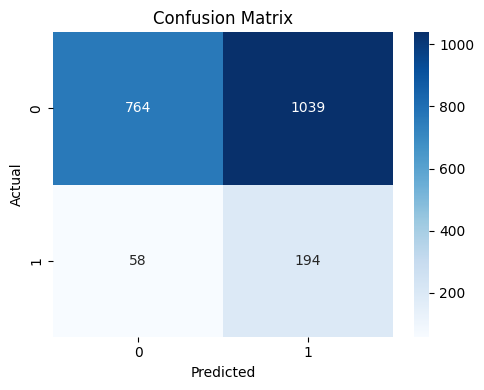

[I 2026-04-01 17:44:27,673] A new study created in memory with name: no-name-ddb42494-7983-4292-a66d-9dd4ab0d697e
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warning


MODEL: logistic


/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ra


=== OPTUNA RESULTS ===
Best trial: 62
Best score (PR-AUC): 0.6450217593838146
Best params: {'penalty': 'l1', 'solver': 'liblinear', 'C': 6.8934962029496125}


/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use '


=== Best Threshold === 0.5000

=== Metrics ===
{'precision': 0.4361493123772102, 'recall': 0.8809523809523809, 'f1': 0.5834428383705651, 'TP': 222.0, 'FP': 287.0, 'FN': 30.0, 'TN': 1516.0, 'pr_auc': 0.6187074840792687}

=== Global Confusion Matrix ===


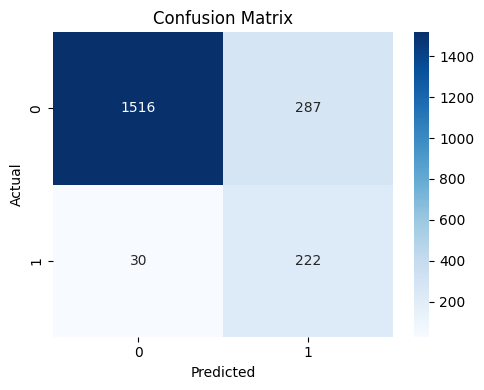

[I 2026-04-01 17:46:32,980] A new study created in memory with name: no-name-987396a9-f6c0-454f-aa17-e71f95e35133



MODEL: random_forest


[I 2026-04-01 17:46:40,857] Trial 0 finished with value: 0.7173121967959758 and parameters: {'n_estimators': 679, 'max_depth': 4, 'min_samples_leaf': 15, 'min_samples_split': 17, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.7173121967959758.
[I 2026-04-01 17:46:49,132] Trial 1 finished with value: 0.7477761847898898 and parameters: {'n_estimators': 718, 'max_depth': 8, 'min_samples_leaf': 14, 'min_samples_split': 15, 'max_features': 0.5, 'bootstrap': True}. Best is trial 1 with value: 0.7477761847898898.
[I 2026-04-01 17:46:54,462] Trial 2 finished with value: 0.7283628757680135 and parameters: {'n_estimators': 577, 'max_depth': 11, 'min_samples_leaf': 17, 'min_samples_split': 15, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.7477761847898898.
[I 2026-04-01 17:47:01,569] Trial 3 finished with value: 0.7204227132595459 and parameters: {'n_estimators': 684, 'max_depth': 11, 'min_samples_leaf': 19, 'min_samples_split': 9, 'max_feat

KeyboardInterrupt: 

In [12]:
results = run_benchmark_pipeline(
    df_btc_media_and_price,
    verbose=True,
    plot_confusion=True
)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("pr_auc", ascending=False)

# =========================
# ADD SUMMARY ROWS
# =========================

# Mean over all models
results_df.loc["mean_all"] = results_df.mean()

# Mean without baselines (dummy + logistic)
results_df.loc["mean_no_baseline"] = results_df.drop(
    index=["dummy", "logistic"], errors="ignore"
).mean()

# Ranking
results_df["rank"] = results_df["pr_auc"].rank(ascending=False)

print("=== Model Benchmarking Results ===")
results_df

In [ ]:
df_btc_media_and_price.shape
df_eth_price.shape
df_btc_price.drop(index=df_btc_price.index[-1], inplace=True)  # Remove last 1 rows with NaN values

In [ ]:
# =========================
# 1. COPY DATA
# =========================

df_eth = df_eth_price.copy()

df_eth["open_time"] = pd.to_datetime(df_eth["open_time"])
df_btc_media_and_price["open_time"] = pd.to_datetime(df_btc_media_and_price["open_time"])


# =========================
# PRIORITY 1 — ETH FEATURES
# =========================

# ETH short-term return (1 day momentum)
df_eth["eth_return_1d"] = df_eth["close"].pct_change()

# ETH medium-term return (7 days trend)
df_eth["eth_return_7d"] = df_eth["close"].pct_change(7)

# ETH short-term volatility (market stress)
df_eth["eth_volatility_7d"] = df_eth["eth_return_1d"].rolling(7).std()

# ETH drawdown (distance from recent peak)
df_eth["eth_cummax"] = df_eth["close"].cummax()
df_eth["eth_drawdown"] = (df_eth["close"] - df_eth["eth_cummax"]) / df_eth["eth_cummax"]


# =========================
# MERGE BTC + ETH
# =========================

df_merged = pd.merge(
    df_btc_media_and_price,
    df_eth,
    on="open_time",
    how="inner",
    suffixes=("_btc", "_eth"),
)


# =========================
# PRIORITY 1 — CROSS FEATURES
# =========================

# BTC / ETH price ratio (market dominance)
df_merged["btc_eth_ratio"] = df_merged["close_btc"] / df_merged["close_eth"]

# Change in BTC/ETH ratio (capital rotation)
df_merged["btc_eth_ratio_return_7d"] = df_merged["btc_eth_ratio"].pct_change(7)


# =========================
# PRIORITY 2 — USEFUL FEATURES
# =========================

# ETH medium-short return (3 days acceleration)
df_merged["eth_return_3d"] = df_merged["close_eth"].pct_change(3)

# ETH long-term volatility (market regime)
df_merged["eth_volatility_30d"] = df_merged["eth_return_1d"].rolling(30).std()

# ETH normalized volume (detect abnormal activity)
df_merged["eth_volume_norm"] = (
    df_merged["volume_eth"] / df_merged["volume_eth"].rolling(30).mean()
)

# Relative performance BTC vs ETH
df_merged["btc_minus_eth_return_7d"] = (
    df_merged["return_7d_btc"] - df_merged["eth_return_7d"]
)


# =========================
# PRIORITY 3 — ADVANCED FEATURES
# =========================

# ETH buy pressure (aggressive buying intensity)
df_merged["eth_buy_pressure"] = (
    df_merged["taker_buy_base_volume_eth"] / df_merged["volume_eth"]
)

# Relative volatility BTC vs ETH
df_merged["btc_eth_vol_ratio"] = (
    df_merged["volatility_7d_btc"] / df_merged["eth_volatility_7d"]
)

# Global market proxy (combined momentum)
df_merged["market_return_proxy_7d"] = (
    0.5 * df_merged["return_7d_btc"] + 0.5 * df_merged["eth_return_7d"]
)


# =========================
# FINAL FEATURE SELECTION
# =========================

eth_feature_cols = [
    "open_time",

    # PRIORITY 1
    "eth_return_1d",
    "eth_return_7d",
    "eth_volatility_7d",
    "eth_drawdown",
    "btc_eth_ratio",
    "btc_eth_ratio_return_7d",

    # PRIORITY 2
    "eth_return_3d",
    "eth_volatility_30d",
    "eth_volume_norm",
    "btc_minus_eth_return_7d",

    # PRIORITY 3
    "eth_buy_pressure",
    "btc_eth_vol_ratio",
    "market_return_proxy_7d",
]

df_eth_features = df_merged[eth_feature_cols].copy()


# =========================
# CLEAN NA
# =========================

df_eth_features = df_eth_features.dropna().reset_index(drop=True)

KeyError: 'open_time'